# Freeviz - zoo data

This notebook performs freeviz on a zoological dataset with 100+ animals. Each animal is annotated with 16 attributes (has hair, has feather, flies etc.) and belongs to one of 7 classes (mammal, fish, etc.)

In [18]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from models import Freeviz
from utils import scale_features, load_zoo_data

import numpy as np
import matplotlib.pyplot as plt
import torch

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [20]:
# data preparation
E_raw, C, names, feature_names, class_names = load_zoo_data(device)
E = scale_features(E_raw)

In [21]:
# training
freeviz = Freeviz(E.shape[1]).to(device)
freeviz.train(E, C)

step: 1 loss: 18686.888671875
step: 2 loss: 18908.298828125
step: 3 loss: 20747.65625
step: 4 loss: 19673.408203125
step: 5 loss: 12314.7578125
step: 6 loss: 11629.3037109375
step: 7 loss: 12073.1474609375
step: 8 loss: 12357.669921875
step: 9 loss: 12604.470703125
step: 10 loss: 12704.3095703125
step: 11 loss: 12857.6171875


## Result visualization

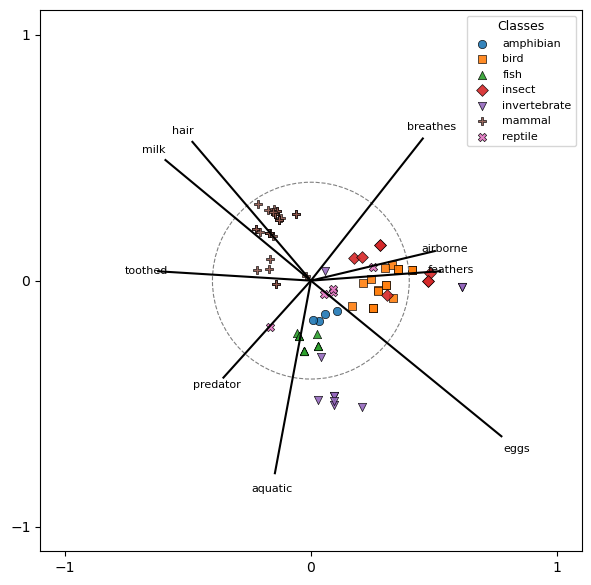

In [ ]:
P = freeviz(E)
A = freeviz.A
P_np = P.detach().cpu().numpy()
C_np = C.detach().cpu().numpy()
A_np = A.detach().cpu().numpy()

unique_classes = np.unique(C_np)

# Define marker shapes
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']

# Use a colormap
cmap = plt.get_cmap('tab10')

plt.figure(figsize=(6, 6))

# Plot each class separately (ensures legend works correctly)
for i, cls in enumerate(unique_classes):
    idx = C_np == cls
    plt.scatter(
        P_np[idx, 0],
        P_np[idx, 1],
        color=cmap(i % 10),
        marker=markers[i % len(markers)],
        label=class_names[int(cls)],
        edgecolors='black',
        linewidths=0.5,
        alpha=0.9
    )

# set and vizualize the minimal length of the feature vecrors to appear
loading_cutoff = 0.4
circle = plt.Circle((0, 0), loading_cutoff, fill=False, linestyle='--', linewidth=0.8, color='gray')
plt.gca().add_patch(circle)

# Axes formatting
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])
plt.gca().set_aspect('equal', 'box')

# Plot projection vectors (A)
for i, vec in enumerate(A_np):
    x, y = vec
    if np.sqrt(x**2 + y**2) > loading_cutoff:
        plt.plot([0, x], [0, y], linestyle='-', linewidth=1.5, color='black')
        plt.text(
            x * 1.08, y * 1.08,
            feature_names[i],
            fontsize=8,
            ha='center',
            va='center'
        )

# Add legend
plt.legend(
    title="Classes",
    loc='upper right',
    frameon=True,
    fontsize=8,
    title_fontsize=9
)

plt.tight_layout()
plt.show()